<div style="background:linear-gradient(135deg,#001F3F 0%,#0093D5 100%);padding:40px 32px;border-left:6px solid #EE3A43;">
<h1 style="color:#fff;font-family:Arial,sans-serif;font-size:28px;margin:0 0 8px;">03a — Complaint Segmentation · Dataset 1</h1>
<h2 style="color:rgba(255,255,255,.75);font-family:Arial,sans-serif;font-size:16px;font-weight:400;margin:0 0 20px;">SpiriCom · Complaint Pattern Analysis · sub_category × province</h2>
<div style="display:flex;gap:32px;flex-wrap:wrap;">
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Input</strong><br/>complaints_clean.parquet</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Method</strong><br/>sub_category groupby · province crosstab · temporal patterns</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Output</strong><br/>data/outputs/complaint_segments.json</div>
</div></div>

---
## What this notebook does

Dataset 1 (complaints) cannot be clustered with KMeans — it has no continuous KPI features.
Instead, **natural complaint segments already exist** in the `sub_category` column (9 distinct values).

This notebook:
1. **Profiles each sub_category segment** — size, unresolved rate, temporal patterns
2. **Province distribution** — which governorates generate which complaint types
3. **Temporal analysis** — monthly and day-of-week patterns per segment
4. **Resolution analysis** — which complaint types are hardest to resolve

The API reads `complaints_clean.parquet` directly — no parquet output needed.
This notebook produces `complaint_segments.json` for offline reporting.

In [1]:
import pandas as pd
import numpy  as np
import json, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_DIR = Path('data')
PROC_DIR = Path('data/processed')
OUT_DIR  = Path('data/outputs')
FIG_DIR  = OUT_DIR / 'figures'
for d in [OUT_DIR, FIG_DIR]: d.mkdir(parents=True, exist_ok=True)

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', purple='#8B5CF6', muted='#6B7280', cyan='#22D3EE')
PALETTE = [HW['red'], HW['blue'], HW['amber'], HW['green'],
           HW['purple'], HW['cyan'], '#F97316', '#EC4899', '#14B8A6']

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white','axes.edgecolor':'#E5E7EB',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
    'axes.grid.axis':'y','grid.color':'#F3F4F6','axes.labelcolor':HW['navy'],
    'axes.labelweight':'bold','axes.titlesize':13,'axes.titleweight':'bold',
    'axes.titlecolor':HW['navy'],'xtick.color':HW['muted'],'ytick.color':HW['muted'],
    'figure.dpi':110,'savefig.dpi':300,'savefig.bbox':'tight',
})
def save_fig(name):
    p = FIG_DIR / f'{name}.png'
    plt.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
def wm(fig):
    fig.text(.99,.01,'SpiriCom · Huawei Technologies Tunisia',
             ha='right',va='bottom',fontsize=7,color=HW['muted'],style='italic')
print('✅ Setup complete')

✅ Setup complete


---
## §1 — Load & Audit Dataset 1

In [2]:
cc = None
for p in [OUT_DIR/'complaints_clean.parquet', PROC_DIR/'complaints_clean.parquet',
          DATA_DIR/'complaints_clean.parquet']:
    if p.exists():
        cc = pd.read_parquet(p)
        cc.columns = cc.columns.str.lower().str.strip()
        print(f'Loaded: {p}')
        print(f'Rows: {len(cc):,}  Cols: {len(cc.columns)}')
        break
if cc is None:
    raise FileNotFoundError('complaints_clean.parquet not found — run NB01')

# ── Identify key columns ─────────────────────────────────────────────
SEG_COL   = next((c for c in ['sub_category','sub_sub_category','category',
                                'complaint_type','segment']
                  if c in cc.columns and cc[c].nunique() > 1), None)
PROV_COL  = next((c for c in ['province','region','city','wilaya'] if c in cc.columns), None)
DATE_COL  = next((c for c in ['opened_at','date','timestamp','creation_date'] if c in cc.columns), None)
UNRES_COL = 'is_unresolved' if 'is_unresolved' in cc.columns else None

# NB03a-FIX-2: normalise province names — strip the French suffix that
# complaints_clean.parquet carries ('TUNIS GOUVERNORAT' → 'TUNIS').
# NB04b/NB07 KPI data uses the short form; without this the frontend
# cannot join complaint province stats with KPI province stats by name.
if PROV_COL and PROV_COL in cc.columns:
    cc[PROV_COL] = (cc[PROV_COL]
        .astype(str)
        .str.replace(r'\s+GOUVERNORAT$', '', regex=True, case=False)
        .str.strip()
        .str.upper())

print(f'\nKey columns:')
print(f'  Segment    : {SEG_COL}  ({cc[SEG_COL].nunique() if SEG_COL else 0} values)')
print(f'  Province   : {PROV_COL} ({cc[PROV_COL].nunique() if PROV_COL else 0} values)')
print(f'  Date       : {DATE_COL}')
print(f'  Unresolved : {UNRES_COL}')

print(f'\n{SEG_COL} distribution:')
dist = cc[SEG_COL].value_counts()
for val, cnt in dist.items():
    bar = '█' * int(cnt / dist.max() * 30)
    print(f'  {str(val):<40s}: {cnt:6,}  ({cnt/len(cc)*100:5.1f}%)  {bar}')

Loaded: data\processed\complaints_clean.parquet
Rows: 25,727  Cols: 23

Key columns:
  Segment    : sub_category  (9 values)
  Province   : province (25 values)
  Date       : opened_at
  Unresolved : is_unresolved

sub_category distribution:
  RÉCLAMATION RÉSEAU MOBILE DATA          : 14,841  ( 57.7%)  ██████████████████████████████
  RÉCLAMATION RÉSEAU MOBILE VOIX          : 10,447  ( 40.6%)  █████████████████████
  G504-RÉCLAMATION RÉSEAU MOBILE DATA 5G  :    383  (  1.5%)  
  RÉCLAMATION INTERNET MOBILE             :     26  (  0.1%)  
  RÉCLAMATION QUALITÉ DE RÉSEAU VOIX      :     20  (  0.1%)  
  B20-RÉCLAMATION RÉSEAU 4G BOX/MIFI      :      4  (  0.0%)  
  001-ECHEC E/R SMS INTERNAT.             :      2  (  0.0%)  
  G505-RÉCLAMATION RÉSEAU MOBILE VOIX 5G  :      2  (  0.0%)  
  474-RÉC INTERNET MOBILE 3G/4G           :      2  (  0.0%)  


---
## §2 — Segment Profiles

In [3]:
# ── 2.1  Build profile per segment ───────────────────────────────────
profiles = []
total    = len(cc)

if DATE_COL:
    cc[DATE_COL] = pd.to_datetime(cc[DATE_COL], errors='coerce')

for cid, (seg_val, grp) in enumerate(cc.groupby(SEG_COL)):
    p = {
        'cluster_id':    cid,
        'cluster_label': str(seg_val),
        'n_users':       int(len(grp)),
        'pct':           round(len(grp) / total * 100, 1),
    }
    # Temporal
    for col in ['month','day_of_week','quarter','week_num']:
        if col in grp.columns:
            p[col] = round(float(grp[col].mean()), 2)
    # Resolution
    if UNRES_COL and UNRES_COL in grp.columns:
        p['unresolved_rate'] = round(float(grp[UNRES_COL].mean()) * 100, 1)
    # Top province
    if PROV_COL and PROV_COL in grp.columns:
        top_prov = grp[PROV_COL].dropna().value_counts()
        if len(top_prov):
            p['top_province'] = str(top_prov.index[0])
            p['top_province_pct'] = round(top_prov.iloc[0] / len(grp) * 100, 1)
    profiles.append(p)

print(f'Profiles built: {len(profiles)} segments\n')
print(f'{"Segment":<40s} {"N":>7}  {"Pct":>6}  {"Unresolved":>11}  Top Province')
print('─' * 90)
for p in profiles:
    print(f'{p["cluster_label"]:<40s} {p["n_users"]:>7,}  {p["pct"]:>5.1f}%'
          f'  {p.get("unresolved_rate",0):>9.1f}%'
          f'  {p.get("top_province","—")} ({p.get("top_province_pct",0):.0f}%)')

Profiles built: 9 segments

Segment                                        N     Pct   Unresolved  Top Province
──────────────────────────────────────────────────────────────────────────────────────────
001-ECHEC E/R SMS INTERNAT.                    2    0.0%       50.0%  NONE (100%)
474-RÉC INTERNET MOBILE 3G/4G                  2    0.0%      100.0%  KAIROUAN (50%)
B20-RÉCLAMATION RÉSEAU 4G BOX/MIFI             4    0.0%       25.0%  TUNIS (25%)
G504-RÉCLAMATION RÉSEAU MOBILE DATA 5G       383    1.5%       50.4%  NONE (40%)
G505-RÉCLAMATION RÉSEAU MOBILE VOIX 5G         2    0.0%        0.0%  NONE (100%)
RÉCLAMATION INTERNET MOBILE                   26    0.1%       88.5%  SIDI BOUZID (77%)
RÉCLAMATION QUALITÉ DE RÉSEAU VOIX            20    0.1%       60.0%  NONE (70%)
RÉCLAMATION RÉSEAU MOBILE DATA            14,841   57.7%       57.4%  TUNIS (11%)
RÉCLAMATION RÉSEAU MOBILE VOIX            10,447   40.6%       38.7%  NONE (13%)


  Saved: data\outputs\figures\fig03a_A_segment_profiles.png


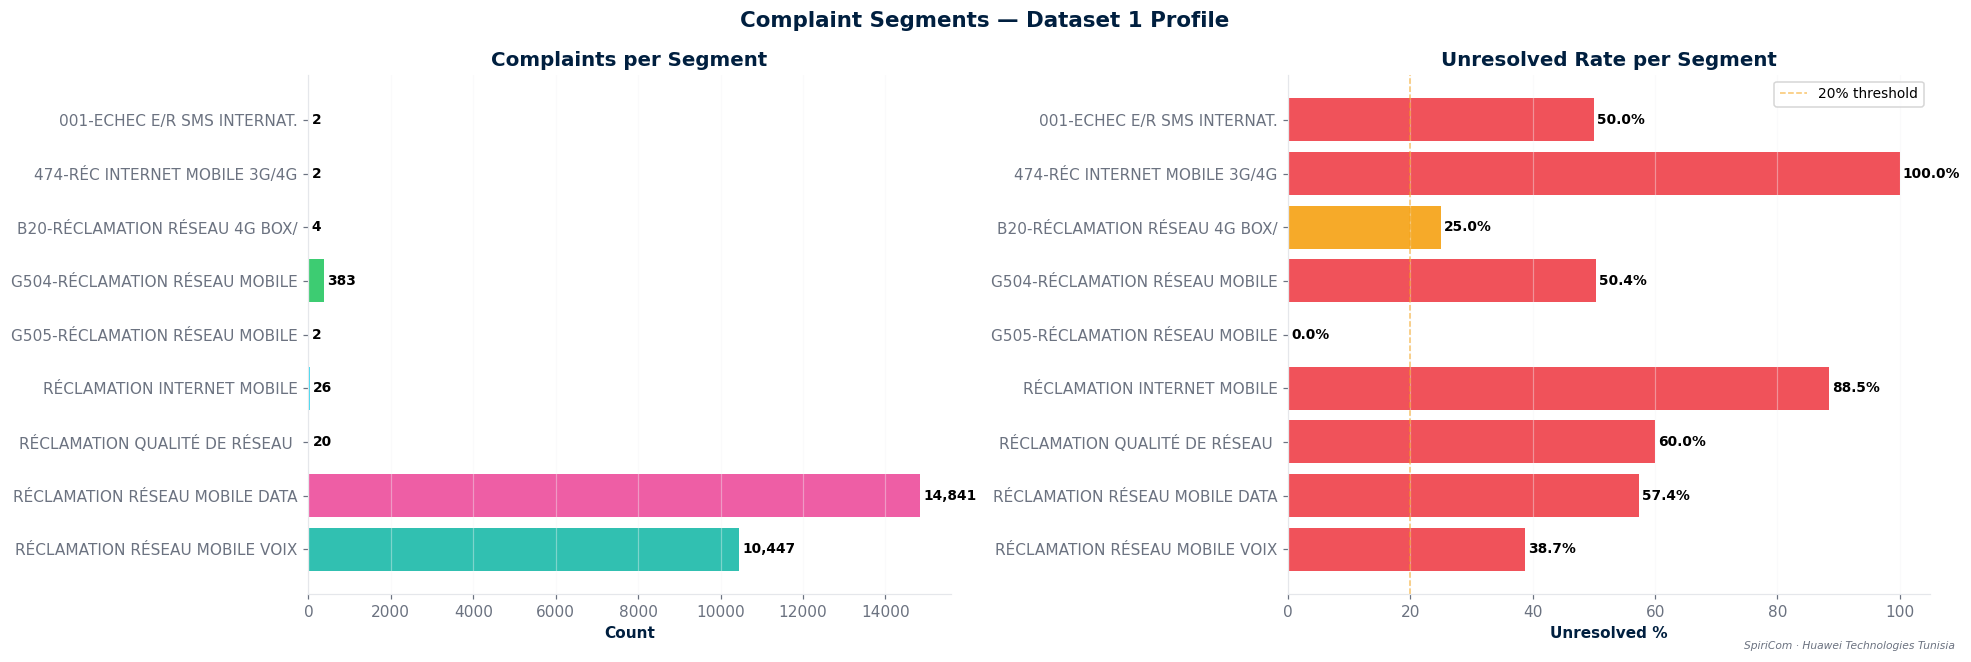

In [4]:
# ── 2.2  Segment size + unresolved rate ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Complaint Segments — Dataset 1 Profile',
             fontsize=14, fontweight='bold', color=HW['navy'])

ax = axes[0]
labels  = [p['cluster_label'][:30] for p in profiles]
sizes   = [p['n_users'] for p in profiles]
colors  = PALETTE[:len(profiles)]
bars = ax.barh(labels[::-1], sizes[::-1], color=colors[::-1], alpha=0.88)
for bar, val in zip(bars, sizes[::-1]):
    ax.text(val + total*0.003, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Complaints per Segment')
ax.set_xlabel('Count')
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

ax = axes[1]
if any('unresolved_rate' in p for p in profiles):
    unres = [p.get('unresolved_rate', 0) for p in profiles]
    bar_colors = [HW['red'] if u > 30 else HW['amber'] if u > 15 else HW['green'] for u in unres]
    bars = ax.barh(labels[::-1], unres[::-1], color=bar_colors[::-1], alpha=0.88)
    for bar, val in zip(bars, unres[::-1]):
        ax.text(val + 0.5, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax.axvline(20, color=HW['amber'], lw=1, ls='--', alpha=0.6, label='20% threshold')
    ax.set_title('Unresolved Rate per Segment')
    ax.set_xlabel('Unresolved %')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)
else:
    ax.text(0.5, 0.5, 'No is_unresolved column', ha='center', va='center',
            transform=ax.transAxes, color=HW['muted'], fontsize=12)

wm(fig); plt.tight_layout()
save_fig('fig03a_A_segment_profiles')
plt.show()

---
## §3 — Province × Segment Distribution

In [5]:
# ── 3.1  Province × sub_category crosstab ────────────────────────────
if PROV_COL:
    cc_valid = cc.dropna(subset=[PROV_COL])
    cross    = pd.crosstab(cc_valid[PROV_COL], cc_valid[SEG_COL], normalize='index')
    cross_pct = (cross * 100).round(1)

    print(f'Province × {SEG_COL} distribution (row-normalised %):')
    print(cross_pct.round(1).to_string())

    # Top complaint type per province
    top_type = cross_pct.idxmax(axis=1)
    print(f'\nDominant complaint type per province:')
    for prov, ctype in top_type.items():
        pct = cross_pct.loc[prov, ctype]
        print(f'  {str(prov):<25s}: {ctype} ({pct:.1f}%)')
else:
    print('⚠ No province/region column found')
    cross_pct = pd.DataFrame()

Province × sub_category distribution (row-normalised %):
sub_category  001-ECHEC E/R SMS INTERNAT.  474-RÉC INTERNET MOBILE 3G/4G  B20-RÉCLAMATION RÉSEAU 4G BOX/MIFI  G504-RÉCLAMATION RÉSEAU MOBILE DATA 5G  G505-RÉCLAMATION RÉSEAU MOBILE VOIX 5G  RÉCLAMATION INTERNET MOBILE  RÉCLAMATION QUALITÉ DE RÉSEAU VOIX  RÉCLAMATION RÉSEAU MOBILE DATA  RÉCLAMATION RÉSEAU MOBILE VOIX
province                                                                                                                                                                                                                                                                                                                     
ARIANA                              0.000                          0.000                               0.000                                   2.100                                   0.000                        0.000                               0.000                          56.500                      

In [ ]:
# ── 3.2  Heatmap: province × segment ─────────────────────────────────
if PROV_COL and len(cross_pct) > 0:
    fig, ax = plt.subplots(figsize=(14, max(8, len(cross_pct)*0.4)))
    fig.suptitle(f'Complaint Type Distribution by Province — {SEG_COL}',
                 fontsize=13, fontweight='bold', color=HW['navy'])

    sns.heatmap(cross_pct, annot=True, fmt='.0f', cmap='Blues',
                ax=ax, cbar_kws={'label': '%'}, linewidths=0.3,
                annot_kws={'size': 8})
    ax.set_xlabel(SEG_COL.replace('_',' ').title())
    ax.set_ylabel('Province')
    ax.tick_params(axis='x', rotation=30)

    wm(fig); plt.tight_layout()
    save_fig('fig03a_B_province_heatmap')
    plt.show()

  Saved: data\outputs\figures\fig03a_B_province_heatmap.png


---
## §4 — Temporal Patterns per Segment

In [ ]:
# ── 4.1  Monthly + day-of-week patterns per segment ──────────────────
if 'month' in cc.columns and 'day_of_week' in cc.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Complaint Temporal Patterns per Segment',
                 fontsize=13, fontweight='bold', color=HW['navy'])

    # Monthly
    ax = axes[0]
    monthly = cc.groupby(['month', SEG_COL]).size().unstack(fill_value=0)
    for i, col in enumerate(monthly.columns):
        ax.plot(monthly.index, monthly[col], color=PALETTE[i % len(PALETTE)],
                linewidth=1.8, label=str(col)[:20], marker='o', markersize=3)
    ax.set_title('Monthly Complaint Volume per Segment')
    ax.set_xlabel('Month')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)

    # Day of week
    ax = axes[1]
    dow = cc.groupby(['day_of_week', SEG_COL]).size().unstack(fill_value=0)
    dow_pct = dow.div(dow.sum(axis=1), axis=0) * 100
    x = np.arange(len(dow_pct))
    width = 0.8 / max(len(dow_pct.columns), 1)
    for i, col in enumerate(dow_pct.columns):
        ax.bar(x + i*width, dow_pct[col], width, color=PALETTE[i % len(PALETTE)],
               alpha=0.85, label=str(col)[:15])
    ax.set_title('Day-of-Week Distribution per Segment (%)')
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('%')
    ax.set_xticks(x + width * len(dow_pct.columns) / 2)
    ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=8)
    ax.legend(fontsize=7, loc='upper right', ncol=2)

    wm(fig); plt.tight_layout()
    save_fig('fig03a_C_temporal_patterns')
    plt.show()
else:
    print('⚠ month/day_of_week columns not found — temporal analysis skipped')

In [ ]:
# ── 5.1  Build complaint_segments.json ───────────────────────────────
# NOTE: `profiles` et `total` sont déjà construits en §2 avec cc
# On ajoute uniquement les champs manquants pour le dashboard

province_dist = []
if PROV_COL and len(cross_pct) > 0:
    seg_vals = list(cross_pct.columns)
    for prov, row in cross_pct.iterrows():
        entry = {'region': str(prov)}
        for sv in seg_vals:
            entry[sv] = float(row[sv])
        province_dist.append(entry)

MIN_N_RELIABLE = 30
small_segs = [p['cluster_label'] for p in profiles if p['n_users'] < MIN_N_RELIABLE]

out = {
    'dataset':               'Dataset 1 — complaints_clean.parquet',
    'segment_column':        SEG_COL,
    'n_segments':            len(profiles),
    'total_records':         total,
    'n_reliable_segments':   len(profiles) - len(small_segs),
    'small_n_segments':      small_segs,
    'small_n_note':          f'Segments avec n<{MIN_N_RELIABLE} : stats non fiables',
    'profiles':              profiles,
    'province_distribution': province_dist,
    'cluster_labels':        {f'cluster_{p["cluster_id"]}': p['cluster_label']
                              for p in profiles},
}

out_path = OUT_DIR / 'complaint_segments.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2, ensure_ascii=False)

print(f'✅ complaint_segments.json saved: {out_path}')

# ── 5.2  Summary ─────────────────────────────────────────────────────
figs = sorted(FIG_DIR.glob('fig03a_*.png'))
print('\n' + '═'*55)
print('NB03a — COMPLAINT SEGMENTATION COMPLETE (Dataset 1)')
print('═'*55)
print(f'  Segment column : {SEG_COL}')
print(f'  Segments       : {len(profiles)}')
print(f'  Total records  : {total:,}')
print(f'  Reliable (n≥30): {out["n_reliable_segments"]}')
print(f'  Provinces      : {len(province_dist)}')
print()
print('  Segment summary:')
for p in profiles:
    unres = f", unresolved={p.get('unresolved_rate') or 0:.0f}%" if p.get('unresolved_rate') is not None else ''
    prov  = f", top={p['top_province']}" if p.get('top_province') else ''
    flag  = ' ⚠ n<30' if p['n_users'] < MIN_N_RELIABLE else ''
    print(f"    [{p['cluster_id']}] {p['cluster_label']:<35s}: {p['n_users']:,} ({p['pct']}%{unres}{prov}){flag}")
print()
print('  Dashboard: UserSegments → Dataset 1 tab  ✅')

---
## §5 — Save Summary JSON

In [ ]:
# ── 5.1  Build complaint_segments.json ───────────────────────────────
province_dist = []
if PROV_COL and len(cross_pct) > 0:
    seg_vals = list(cross_pct.columns)
    for prov, row in cross_pct.iterrows():
        # NB03a-FIX-1: label keys — self-documenting and index-safe
        entry = {'region': str(prov)}
        for sv in seg_vals:
            entry[sv] = float(row[sv])
        province_dist.append(entry)

# NB03a-FIX-3: small-N flag — segments with n<30 have unreliable
# unresolved rates (e.g. 100% from n=2 is sampling noise).
MIN_N_RELIABLE = 30
small_segs = [p['cluster_label'] for p in profiles if p['n_users'] < MIN_N_RELIABLE]

out = {
    'dataset':        'Dataset 1 — complaints_clean.parquet',
    'segment_column': SEG_COL,
    'n_segments':     len(profiles),
    'total_records':  total,
    'profiles':       profiles,
    'province_distribution': province_dist,
    # NB03a-FIX-1: cluster_labels kept for back-compat but province_distribution
    # now uses label keys directly — no decoding via cluster_X needed.
    'cluster_labels': {f'cluster_{i}': p['cluster_label'] for i, p in enumerate(profiles)},
    # NB03a-FIX-3
    'n_reliable_segments':  len(profiles) - len(small_segs),
    'small_n_segments':     small_segs,
    'small_n_note':         f'Segments with n<{MIN_N_RELIABLE}: stats unreliable (sampling noise)',
}

out_path = OUT_DIR / 'complaint_segments.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2, ensure_ascii=False)

print(f'✅ complaint_segments.json saved: {out_path}')

# ── 5.2  Summary ─────────────────────────────────────────────────────
figs = sorted(FIG_DIR.glob('fig03a_*.png'))
print('\n' + '═'*55)
print('NB03a — COMPLAINT SEGMENTATION COMPLETE (Dataset 1)')
print('═'*55)
print(f'  Segment column : {SEG_COL}')
print(f'  Segments       : {len(profiles)}')
print(f'  Total records  : {total:,}')
print(f'  Provinces      : {len(province_dist)}')
print()
print('  Segment summary:')
for p in profiles:
    unres = f", unresolved={p.get('unresolved_rate',0):.0f}%" if 'unresolved_rate' in p else ''
    print(f'    [{p["cluster_id"]}] {p["cluster_label"]:<35s}: {p["n_users"]:,} ({p["pct"]}%{unres})')
print()
print(f'  Figures ({len(figs)}):')
for fp in figs:
    print(f'    {fp.name}')
print()
print('  Dashboard: UserSegments → Dataset 1 tab  ✅')
print('  API reads complaints_clean.parquet directly (no parquet output needed)')

---
## Summary

### Dataset 1 Complaint Segments

| Output | Description |
|--------|-------------|
| `data/outputs/complaint_segments.json` | Profiles + province distribution |
| `fig03a_A_segment_profiles.png` | Segment size + unresolved rate |
| `fig03a_B_province_heatmap.png` | Province × complaint type heatmap |
| `fig03a_C_temporal_patterns.png` | Monthly + day-of-week patterns |

### Dashboard integration
```
NB03a → complaint_segments.json  (optional reporting)
         ↓
GET /api/analytics/segments/complaints/profiles        → Dataset 1 tab
GET /api/analytics/segments/complaints/region-distribution
         ↓
UserSegments.jsx — Dataset 1 tab auto-populates
```

> **Next:** Run `03b_Segmentation_D2.ipynb` for subscriber KMeans clustering.

---
*SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia · PFE 2026*